### Based on [Climada tutorial](https://github.com/CLIMADA-project/climada_python/blob/main/doc/tutorial/climada_util_api_client.ipynb)

In [2]:
from climada.util.api_client import Client

client = Client() # initialise client to retrieve datasets via Climada API

In [3]:
import pandas as pd

data_types = client.list_data_type_infos()

dtf = pd.DataFrame(data_types)

dtf.sort_values("data_type_group") # summarise metadata of available datasets


,data_type,data_type_group,status,description,properties,key_reference,version_notes
6,centroids,centroids,active,None,"[{'property': 'res_arcsec_land', 'mandatory': ...",[],[]
0,litpop,exposures,active,A global high-resolution asset exposure datase...,"[{'property': 'spatial_coverage', 'mandatory':...","[{'ref_no': 1, 'ref_url': 'https://doi.org/10....","[{'version': 'v2', 'notes': 'Countries with no..."
4,crop_production,exposures,active,Historical and twenty-first century crop produ...,"[{'property': 'crop', 'mandatory': True, 'desc...","[{'ref_no': 1, 'ref_url': 'https://doi.org/10....",[]
10,crops,exposures,active,Crop exposure for Switzerland in 2021 obtained...,"[{'property': 'crop', 'mandatory': True, 'desc...","[{'ref_no': 1, 'ref_url': 'https://doi.org/10....",[]
1,tropical_cyclone,hazard,active,Tropical cyclone wind footprints (m/s) at 150 ...,"[{'property': 'spatial_coverage', 'mandatory':...","[{'ref_no': 1, 'ref_url': 'https://doi.org/10....","[{'version': 'v2', 'notes': 'Higher resolution..."
2,wildfire,hazard,active,"Global wildfire dataset at 4km resolution, bas...","[{'property': 'res_arcsec', 'mandatory': True,...","[{'ref_no': 1, 'ref_url': 'https://gmd.coperni...",[]
3,river_flood,hazard,active,River flood [flood depth in meters and flooded...,"[{'property': 'res_arcsec', 'mandatory': True,...","[{'ref_no': 1, 'ref_url': 'https://www.nature....","[{'version': 'v2', 'notes': 'Higher resolution..."
5,storm_europe,hazard,active,European winter storm [gust in meters per seco...,"[{'property': 'data_source', 'mandatory': Fals...","[{'ref_no': 1, 'ref_url': 'https://www.nat-haz...",[]
7,relative_cropyield,hazard,active,Historical and twenty-first century crop produ...,"[{'property': 'climate_scenario', 'mandatory':...","[{'ref_no': 1, 'ref_url': 'https://doi.org/10....",[]
8,earthquake,hazard,active,Earthquake hazard sets at 150 arcsec (ca. 4km)...,"[{'property': 'res_arcsec', 'mandatory': True,...","[{'ref_no': 1, 'ref_url': None, 'key_reference...",[]


In [4]:
#  Choose the litpop exposure dataset. This dataset models asset values globally based on population density and nightlight
# intensity seen in satellite imaging. It is used within Climada to model the economic impact of natural hazards.
#  See info on the LitPop model for modelling global asset values: 
# https://climada-python.readthedocs.io/en/stable/tutorial/climada_entity_LitPop.html)
litpop_dataset_infos = client.list_dataset_infos(data_type="litpop")

# Retrieve a dictionary of possible values for properties of a data type
all_properties = client.get_property_values(litpop_dataset_infos) 

all_properties.keys() # return list of properties

dict_keys(['res_arcsec', 'exponents', 'fin_mode', 'spatial_coverage', 'country_iso3alpha', 'country_name', 'country_iso3num'])

In [5]:
# return the values corresponding with UK. This output tells us the possible values for each property for the UK
# we use these when we calculate the impact of hazards
client.get_property_values(litpop_dataset_infos, known_property_values={"country_name": "United Kingdom"})

{'res_arcsec': ['150'],
 'exponents': ['(3,0)', '(0,1)', '(1,1)'],
 'fin_mode': ['pc', 'pop'],
 'spatial_coverage': ['country'],
 'country_iso3alpha': ['GBR'],
 'country_name': ['United Kingdom'],
 'country_iso3num': ['826']}

In [6]:
# retrieve a list of dictionary keys for the 'river_flood' hazard object
fl_dataset_infos = client.list_dataset_infos(data_type="river_flood")

# list the values of the river_flood hazard object corresponding with the UK
client.get_property_values(fl_dataset_infos, known_property_values={"country_name": "United Kingdom"})

# this output tells us the climate sceniarios available and the year ranges where we can project impact

{'res_arcsec': ['150'],
 'climate_scenario': ['rcp26', 'rcp85', 'historical', 'rcp60'],
 'year_range': ['2010_2030',
  '2030_2050',
  '2050_2070',
  '2070_2090',
  '1980_2000'],
 'spatial_coverage': ['country'],
 'country_iso3alpha': ['GBR'],
 'country_name': ['United Kingdom'],
 'country_iso3num': ['826']}

<GeoAxes: title={'center': 'RF max intensity at each point'}>

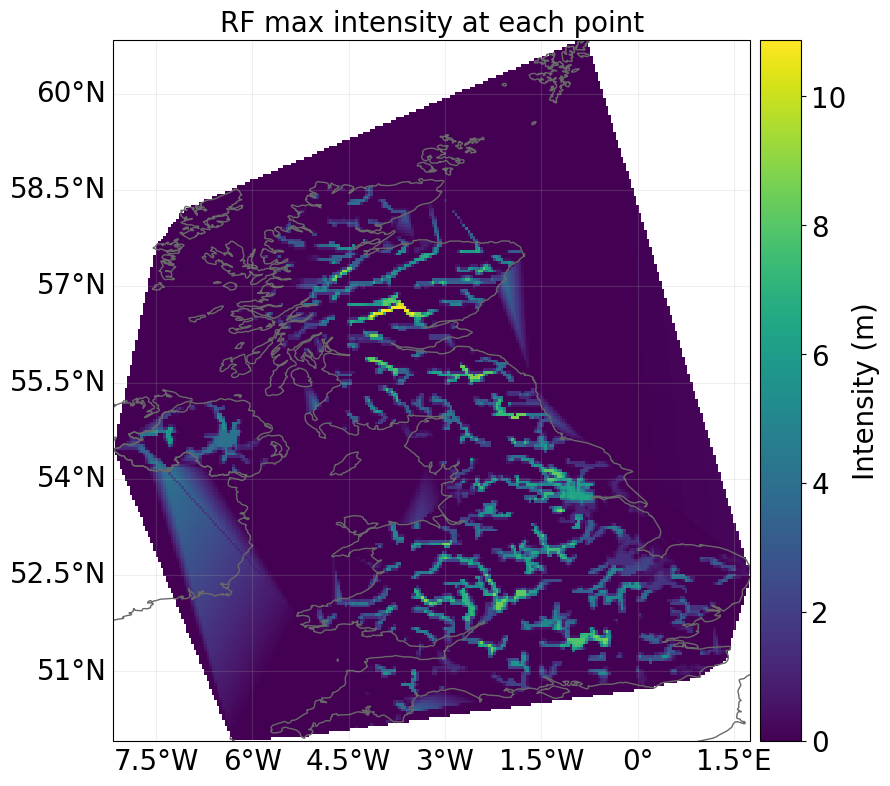

In [7]:
# retrieve the hazard projections for the UK, given climate scenario rcp85 and year range 2050-2070 
# (possible values known from the output of the previous cell)
fl_UK = client.get_hazard(
    "river_flood",
    properties={
        "country_iso3alpha": "GBR",
        "climate_scenario": 'rcp85',
        "year_range": "2050_2070"
  }
)

fl_UK.plot_intensity(0) # plot the hazard intensity

In [8]:
# get asset values for the UK, taken from the litpop exposure dataset. 
# Choice of financial mode (fin_mode) is crucial, worth seeing the difference in results. I chose 'pc' (produced capital)
litpop_default = client.get_property_values(
    litpop_dataset_infos, known_property_values={"fin_mode":"pc", "exponents": "(1,1)"}
)

litpop = client.get_litpop(country="United Kingdom")

<Axes: title={'center': 'RF 1: Flood Europe JRC Commercial noPAA'}, xlabel='Intensity (m)', ylabel='Impact (%)'>

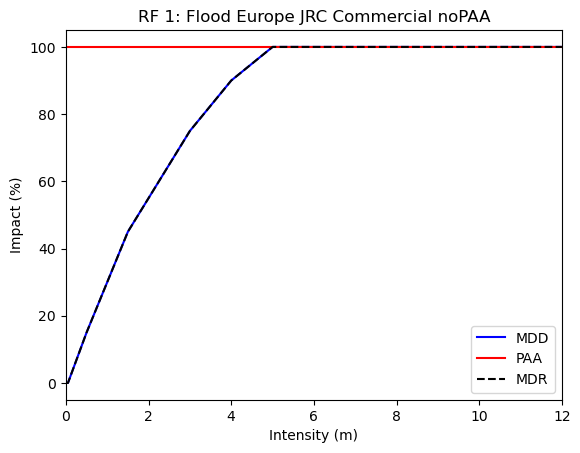

In [9]:
# Now we have retrieved modelled asset values in the UK and projected river flood impact.
# Next we use an impact function to calculate the economic impact of the hazard on the asset values.
from climada.entity.impact_funcs import ImpactFuncSet
from climada_petals.entity.impact_funcs.river_flood import ImpfRiverFlood

imp_fun = ImpfRiverFlood.from_jrc_region_sector(region="Europe", sector="commercial") # import european river flood impact function
imp_fun.haz_type = "RF" # set hazard type to river flood
imp_fun.id = 1 # set id to 1 (not sure what the IDs are about)
imp_fun.check() # verify what you have retrieved
imp_fun.plot() # plot the function

In [10]:
imp_fun_set = ImpactFuncSet([imp_fun]) # create an impact function set object

litpop.impact_funcs = imp_fun_set # set the impact function property of 'litpop' exposure object we defined to our impact function set

In [ ]:
from climada.engine import ImpactCalc

impact = ImpactCalc(litpop, imp_fun_set, fl_UK).impact()

2025-05-02 21:20:58,467 - climada.util.coordinates - WARNING - Distance to closest centroid is greater than 100km for 2 coordinates.


In [ ]:
impact.impact_per_year() # return the economic impact each year in the date range

{2050: 375514952415.7457,
 2051: 36988900192.64549,
 2052: 85855384116.44406,
 2053: 45018556053.67828,
 2054: 393789414426.1801,
 2055: 59008668413.72368,
 2056: 519565462777.7244,
 2057: 1424839965749.4558,
 2058: 623350136887.2643,
 2059: 314795587221.2959,
 2060: 216508433292.59216,
 2061: 90235255877.11691,
 2062: 21417681507.111237,
 2063: 68323332624.098465,
 2064: 311039423536.068,
 2065: 98775412442.65202,
 2066: 18800956394.228954,
 2067: 423292746395.9322,
 2068: 341154124666.4062,
 2069: 557049085064.6575}

In [ ]:
# Below is my attempt to create a custom exposure dataset to see the impact of river flooding on a specific office in London.
# the result is zero impact, and I'm not sure if that's because there is no impact or if I did something wrong.
from climada.entity import Exposures

# define a dataframe with the properties of the exposure object. Copilot told me how to do this.
lon_office= pd.DataFrame({
    'lat': 51.51162260254003,
    'lon': -0.08910310010552419,
    'value': 5000000,
    'value_unit': 'GBP',
    'crs': 'EPSG:4979',
    'description': '18 St Swithin\'s Ln',
    'ref_year': 2025,
    "region_id": 1,
    "impf_RF": 1},
    index=[0]
)
lon_office_exposure = Exposures(lon_office) # create the exposure object

In [16]:
lon_office_impact = ImpactCalc(lon_office_exposure, imp_fun_set, fl_UK).impact()

In [17]:
lon_office_impact.impact_per_year() # return the economic impact each year in the date range

{2050: 0.0,
 2051: 0.0,
 2052: 0.0,
 2053: 0.0,
 2054: 0.0,
 2055: 0.0,
 2056: 0.0,
 2057: 0.0,
 2058: 0.0,
 2059: 0.0,
 2060: 0.0,
 2061: 0.0,
 2062: 0.0,
 2063: 0.0,
 2064: 0.0,
 2065: 0.0,
 2066: 0.0,
 2067: 0.0,
 2068: 0.0,
 2069: 0.0}